# Импорт библиотек и настройка среды

In [1444]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportion_confint
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [1445]:
pd.set_option("display.max_columns", 100)
pd.set_option('display.max_colwidth', None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Удобства для навигации

In [1446]:
help = dict()

# Загрузка датасета и его краткий осмотр

Загрузка датасета

In [1447]:
data = pd.read_csv("../data/raw/cs-training.csv")
data = data.drop(columns=["Unnamed: 0"], errors="ignore")

In [1448]:
help["переменная датасета"] = "data"

Улучшение наименования столбцов

In [1449]:
data = data.rename(columns={
    "SeriousDlqin2yrs": "target",
    "RevolvingUtilizationOfUnsecuredLines": "revolving_utilization",
    "age": "age",
    "NumberOfTime30-59DaysPastDueNotWorse": "num_30_59_days_late",
    "DebtRatio": "debt_ratio",
    "MonthlyIncome": "monthly_income",
    "NumberOfOpenCreditLinesAndLoans": "num_open_credit_lines",
    "NumberOfTimes90DaysLate": "num_90_days_late",
    "NumberRealEstateLoansOrLines": "num_real_estate_loans",
    "NumberOfTime60-89DaysPastDueNotWorse": "num_60_89_days_late",
    "NumberOfDependents": "num_dependents"
})

Формирование описания признаков

In [1450]:
data_dictionary = pd.DataFrame({
    "column": data.columns,
    "description": [
        "Был ли у человека за последние 2 года случай просрочки на 90 дней или более",
        "Общий баланс по кредитным картам и личным кредитным линиям, кроме недвижимости и долгов в рассрочку, например автокредитов, делённый на сумму кредитных лимитов",
        "Возраст заёмщика в годах",
        "Количество раз, когда заёмщик имел просрочку 30–59 дней, но не хуже, за последние 2 года",
        "Ежемесячные выплаты по долгам, алименты и расходы на проживание, делённые на ежемесячный валовый доход",
        "Ежемесячный доход",
        "Количество открытых кредитов, например автокредит или ипотека, и кредитных линий, например кредитных карт",
        "Количество раз, когда заёмщик имел просрочку 90 дней или более",
        "Количество ипотечных и других кредитов, связанных с недвижимостью, включая кредитные линии под залог жилья",
        "Количество раз, когда заёмщик имел просрочку 60–89 дней, но не хуже, за последние 2 года",
        "Количество иждивенцев в семье, не включая самого заёмщика: супруг/супруга, дети и т. д."
    ],
    "types": [
        "binary",
        "percent",
        "integer",
        "count",
        "percent",
        "float",
        "count",
        "count",
        "count",
        "count",
        "count"
    ],
    "role": [
        "target",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature"
    ]
})

In [1451]:
help["описание признаков"] = "data_dictionary"

Описание признаков

In [1452]:
data_dictionary

,column,description,types,role
0,target,Был ли у человека за последние 2 года случай просрочки на 90 дней или более,binary,target
1,revolving_utilization,"Общий баланс по кредитным картам и личным кредитным линиям, кроме недвижимости и долгов в рассрочку, например автокредитов, делённый на сумму кредитных лимитов",percent,feature
2,age,Возраст заёмщика в годах,integer,feature
3,num_30_59_days_late,"Количество раз, когда заёмщик имел просрочку 30–59 дней, но не хуже, за последние 2 года",count,feature
4,debt_ratio,"Ежемесячные выплаты по долгам, алименты и расходы на проживание, делённые на ежемесячный валовый доход",percent,feature
5,monthly_income,Ежемесячный доход,float,feature
6,num_open_credit_lines,"Количество открытых кредитов, например автокредит или ипотека, и кредитных линий, например кредитных карт",count,feature
7,num_90_days_late,"Количество раз, когда заёмщик имел просрочку 90 дней или более",count,feature
8,num_real_estate_loans,"Количество ипотечных и других кредитов, связанных с недвижимостью, включая кредитные линии под залог жилья",count,feature
9,num_60_89_days_late,"Количество раз, когда заёмщик имел просрочку 60–89 дней, но не хуже, за последние 2 года",count,feature


Размерность датасета

In [1453]:
data.shape

(150000, 11)

Столбцы и типы данных датасета

In [1454]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   target                 150000 non-null  int64  
 1   revolving_utilization  150000 non-null  float64
 2   age                    150000 non-null  int64  
 3   num_30_59_days_late    150000 non-null  int64  
 4   debt_ratio             150000 non-null  float64
 5   monthly_income         120269 non-null  float64
 6   num_open_credit_lines  150000 non-null  int64  
 7   num_90_days_late       150000 non-null  int64  
 8   num_real_estate_loans  150000 non-null  int64  
 9   num_60_89_days_late    150000 non-null  int64  
 10  num_dependents         146076 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 12.6 MB


Краткий взгляд на данные

In [1455]:
data.sample(3)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
119456,0,0.2569,76,0,0.7345,"11,000.0000",26,0,2,0,0.0000
137326,1,0.6126,53,2,1.0983,"9,200.0000",18,0,6,0,2.0000
142171,0,0.0649,70,0,0.2524,"4,713.0000",11,0,2,0,0.0000


**Вывод по блоку:**
1. данных достаточно много;
2. пропусков в данных не много, что хорошо;
3. типы признаков все числовые, что хорошо, не нужно будет выполнять кодирование категориальных признаков.

# Общая проверка качества данных

Проверка наличия дубликатов

In [1456]:
duplicates_summary = (
    data.duplicated()
    .agg(["sum", "mean"])
    .T
    .rename({"sum": "duplicate_count", "mean": "duplicate_percent"})
)
duplicates_summary["duplicate_percent"] = duplicates_summary["duplicate_percent"] * 100

In [1457]:
help["количество дубликатов в данных"] = "duplicates_summary"

In [1458]:
duplicates_summary

duplicate_count     609.0000
duplicate_percent     0.4060
dtype: float64

Первичная проверка наличия пропусков

In [1459]:
missing_summary = (
    data.isna()
    .agg(["sum", "mean"])
    .T
    .rename(columns={"sum": "missings_count", "mean": "missings_percent"})
)
missing_summary["missings_percent"] = missing_summary["missings_percent"] * 100

In [1460]:
help["количество пропусков в данных"] = "missing_summary"

In [1461]:
missing_summary

,missings_count,missings_percent
target,0.0000,0.0000
revolving_utilization,0.0000,0.0000
age,0.0000,0.0000
num_30_59_days_late,0.0000,0.0000
debt_ratio,0.0000,0.0000
monthly_income,"29,731.0000",19.8207
num_open_credit_lines,0.0000,0.0000
num_90_days_late,0.0000,0.0000
num_real_estate_loans,0.0000,0.0000
num_60_89_days_late,0.0000,0.0000


**Вывод по блоку:**
1. Данные, кажутся, качественными;
2. Дубликаты есть, но их не много, так что их наличие незначительно, нужно будет просто потом их удалить;
3. Пропусков не много, но их количество не позволит их безболезненно удалить, поэтому сначала нужно посмотреть на зависимости между признаками.

# Распределение целевой переменной

Распределение целевой переменной

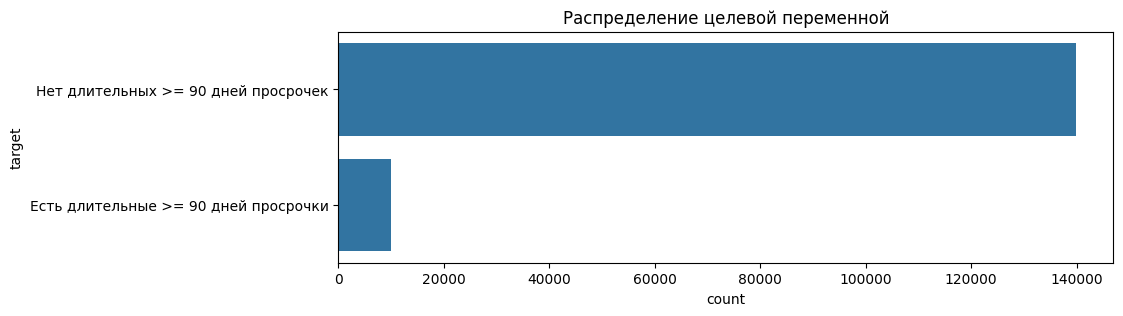

In [1462]:
plt.figure(figsize=(10, 3))
sns.countplot(data, y="target")
plt.title("Распределение целевой переменной")
plt.yticks([0, 1], ["Нет длительных >= 90 дней просрочек", "Есть длительные >= 90 дней просрочки"], rotation=0)
plt.show()

Соотношение классов

In [1463]:
target_class_stats = (
    data["target"]
    .value_counts()
    .rename_axis("target")
    .reset_index(name="count")
)
target_class_stats["ratio"] = target_class_stats["count"] / target_class_stats["count"].sum() * 100

In [1464]:
help["оценка соотношения классов"] = "target_class_stats"

In [1465]:
target_class_stats

,target,count,ratio
0,0,139974,93.3160
1,1,10026,6.6840


Доверительный интервал (интервал вероятных значений)

In [1466]:
def proportion_ci(series, positive_class=1, alpha=0.05, method="wilson"):
    x = series.dropna()

    count = (x == positive_class).sum()
    nobs = x.shape[0]
    proportion = count / nobs

    ci_low, ci_high = proportion_confint(
        count=count,
        nobs=nobs,
        alpha=alpha,
        method=method
    )

    return pd.Series({
        "proportion": proportion,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "count": count,
        "n": nobs
    })

In [1467]:
target_proportion_ci = proportion_ci(data["target"])

In [1468]:
help["доверительный интервал для вероятности дефолта"] = "target_proportion_ci"

In [1469]:
target_proportion_ci

proportion         0.0668
ci_low             0.0656
ci_high            0.0681
count         10,026.0000
n            150,000.0000
dtype: float64

**Вывод по блоку:**
1. Присутствует большой дисбаланс классов;
2. В качестве метрики качества accuracy будет неинформативной, стоит использовать ROC-AUC или PR-ROC;
3. Вроятность дефолта по кредитам лежит в диапазоне от **0.0656** до **0.0681**.

# Анализ распределений признаков, выбросов и невозможных значений

Иллюстрация распределений признаков

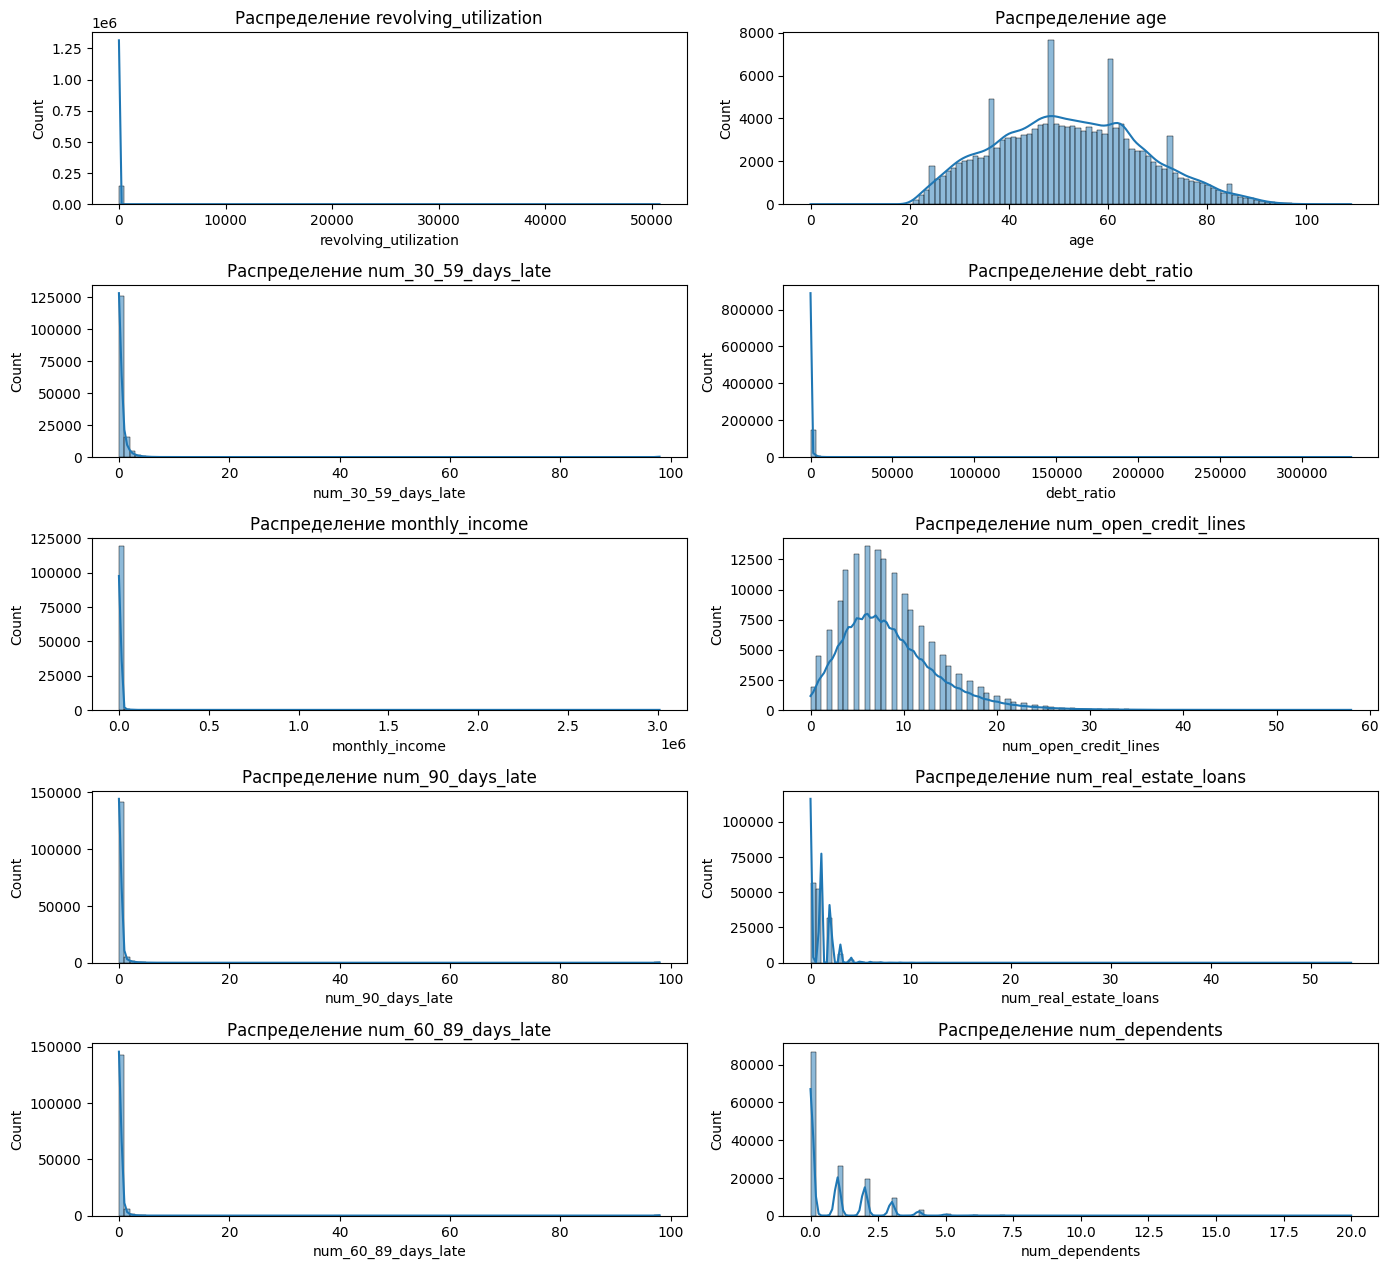

In [1470]:
columns = data.drop(columns="target").columns
num_columns = len(columns)

plt.figure(figsize=(14, 25))
for i, column in enumerate(columns):
    plt.subplot(num_columns, 2, i + 1)
    sns.histplot(data=data, x=column, bins=100, kde=True)
    plt.title(f"Распределение {column}")

plt.tight_layout()
plt.show()

Числовые характеристики признаков

In [1471]:
feature_values_summary = data.drop(columns="target").describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T

feature_values_summary["skew"] = data.drop(columns="target").skew()

In [1472]:
help["числовые характеристики признаков"] = "feature_values_summary"

In [1473]:
feature_values_summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew
revolving_utilization,"150,000.0000",6.0484,249.7554,0.0000,0.0000,0.0000,0.0299,0.1542,0.5590,1.0000,1.0930,"50,708.0000",97.6316
age,"150,000.0000",52.2952,14.7719,0.0000,24.0000,29.0000,41.0000,52.0000,63.0000,78.0000,87.0000,109.0000,0.1890
num_30_59_days_late,"150,000.0000",0.4210,4.1928,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,4.0000,98.0000,22.5971
debt_ratio,"150,000.0000",353.0051,"2,037.8185",0.0000,0.0000,0.0043,0.1751,0.3665,0.8683,"2,449.0000","4,979.0400","329,664.0000",95.1578
monthly_income,"120,269.0000","6,670.2212","14,384.6742",0.0000,0.0000,"1,300.0000","3,400.0000","5,400.0000","8,249.0000","14,587.6000","25,000.0000","3,008,750.0000",114.0403
num_open_credit_lines,"150,000.0000",8.4528,5.1460,0.0000,0.0000,2.0000,5.0000,8.0000,11.0000,18.0000,24.0000,58.0000,1.2153
num_90_days_late,"150,000.0000",0.2660,4.1693,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,3.0000,98.0000,23.0873
num_real_estate_loans,"150,000.0000",1.0182,1.1298,0.0000,0.0000,0.0000,0.0000,1.0000,2.0000,3.0000,4.0000,54.0000,3.4825
num_60_89_days_late,"150,000.0000",0.2404,4.1552,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,2.0000,98.0000,23.3317
num_dependents,"146,076.0000",0.7572,1.1151,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,3.0000,4.0000,20.0000,1.5882


Анализ экстремальных значений

In [1474]:
feature_extreeme_values = data.drop(columns="target").quantile(
    [0.0, 0.005, 0.0075, 0.01, 0.10, 0.5, 0.90, 0.99, 0.995, 0.9975, 1.0]
).T

In [1475]:
help["анализ экстремальных значений"] = "feature_extreeme_values"

In [1476]:
feature_extreeme_values

,0.0000,0.0050,0.0075,0.0100,0.1000,0.5000,0.9000,0.9900,0.9950,0.9975,1.0000
revolving_utilization,0.0000,0.0000,0.0000,0.0000,0.0030,0.1542,0.9813,1.0930,1.3663,1.9900,"50,708.0000"
age,0.0000,23.0000,23.0000,24.0000,33.0000,52.0000,72.0000,87.0000,89.0000,91.0000,109.0000
num_30_59_days_late,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,4.0000,5.0000,6.0000,98.0000
debt_ratio,0.0000,0.0000,0.0000,0.0000,0.0309,0.3665,"1,267.0000","4,979.0400","6,186.0100","7,805.0025","329,664.0000"
monthly_income,0.0000,0.0000,0.0000,0.0000,"2,005.0000","5,400.0000","11,666.0000","25,000.0000","35,000.0000","50,145.2000","3,008,750.0000"
num_open_credit_lines,0.0000,0.0000,0.0000,0.0000,3.0000,8.0000,15.0000,24.0000,27.0000,30.0000,58.0000
num_90_days_late,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,3.0000,4.0000,6.0000,98.0000
num_real_estate_loans,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,2.0000,4.0000,6.0000,7.0000,54.0000
num_60_89_days_late,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,3.0000,4.0000,98.0000
num_dependents,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,4.0000,5.0000,5.0000,20.0000


**Вывод по блоку:**
1. Все признаки имеют ассиметричное распределение с тяжёлыми правыми хвостами;
2. Почти все признаки имеют серьёзные аномальные значения, сильно выбивающиеся из основного распределения;
3. В признаках `revolving_utilization`, `num_30_59_days_late`, `debt_ratio`, `num_open_credit_lines`, `num_90_days_late`, `num_real_estate_loans`, `num_60_89_days_late` аномальные значения, скорее всего являются ошибочными, требуется дополнительное рассмотрение;
4. Почти все выбросы из данных будут иметь негативное влияние на качество обучения, в том числе линейных моделей, которое приведёт к значительному снижению точности предсказания. Нужно будет продумать стратегии их обработки.

# Подробный анализ значений признаков (невозможные значения и выбросы)

## target (целевая переменная)

Данный признак говорит от том, были ли у человека случаи просрочки на 90 и более дней в за последние 2 года.

У целевой переменной могут быть странности. Стоит проверить, что люди, имеющие просрочки 90 и более дней за последние 2 года, имеют соответствующие просрочки. Кроме того, у человека могут быть просрочки в 90 и более дней (`num_90_days_late` > 0), но при это иметь `target` = 0.

Количество вероятных ошибок

In [1477]:
num_target_1_with_and_0_num_90_days_late = data.query("target == 1 & num_90_days_late == 0").shape[0]
num_target_0_with_and_over_0_num_90_days_late = data.query("target == 0 & num_90_days_late > 0").shape[0]

In [1478]:
help["количество target = 1 и num_90_days_late = 0"] = "num_target_1_with_and_0_num_90_days_late"
help["количество target = 0 и num_90_days_late > 0"] = "num_target_0_with_and_over_0_num_90_days_late"

In [1479]:
num_target_1_with_and_0_num_90_days_late, num_target_0_with_and_over_0_num_90_days_late

(6554, 4866)

Беглый осмотр данных с `target` = 1 и `num_90_days_late` = 0

In [1480]:
data.query("target == 1 & num_90_days_late == 0").loc[:, [
    "target",
    "num_30_59_days_late",
    "num_90_days_late",
    "num_60_89_days_late"
    ]].sample(40)

,target,num_30_59_days_late,num_90_days_late,num_60_89_days_late
134032,1,0,0,0
140661,1,2,0,0
130610,1,0,0,0
19585,1,3,0,1
49855,1,0,0,0
106852,1,1,0,0
6292,1,4,0,0
99624,1,0,0,0
73022,1,1,0,0
74152,1,0,0,0


Беглый осмотр данных с `target` = 0 и `num_90_days_late` > 0

In [1481]:
data.query("target == 0 & num_90_days_late > 0").loc[:, [
    "target",
    "num_30_59_days_late",
    "num_90_days_late",
    "num_60_89_days_late"
    ]].sample(40)

,target,num_30_59_days_late,num_90_days_late,num_60_89_days_late
81072,0,1,1,0
17858,0,0,1,0
63042,0,0,2,0
84546,0,4,1,1
52641,0,1,1,0
65217,0,2,1,0
33979,0,0,1,0
64420,0,0,1,0
3429,0,0,2,0
146650,0,0,1,0


**Вывод по признаку:**
Признак очень странный. Если думать, что `target` - есть ли у человека за последние 2 года просрочки в 90 и более дней, то есть куча представителей, значение которых не объясняется текущим датасетом - `num_90_days_late` > 0 и `target` = 0 (4866, порядка 40%) или `num_90_days_late` = 0 и `target` = 1 (6554, порядка 60%).

Рассмотрим первый случай - `num_90_days_late` > 0 и `target` = 0. Данное явление может иметь следующую природу:
1. Ошибки;
2. `target` проставлялся до того, как простравлялся `num_90_days_late` и при проставленнии `target` наступления просрочки в 90 дней ещё не было;
3. У данных людей нет кридитной истории в 2 года, поэтому для них `target` ещё не проставлялся;
4. Другие объяснения, о которых я не знаю.

Рассмотрим второй случай - `num_90_days_late` = 0 и `target` = 1. Данное явление может иметь следующую природу:
1. Ошибки;
2. В таблице отмечаются незакрытые просрочки, а закрытые обнуляются, что и объясняет 0 в `num_90_days_late` и 1 в `target`;
3. Есть какие-то другие типы кредитов, по которым есть просрочки в 90 дней и более и которые не отображены в данной таблице;
4. Другие объяснения о которых я не знаю.

К сожалению, я не смог найти объяснения этим явлениям на странице датасета на Kaggle, поэтмоу выяснить верность моих предположений я могу сделать только сделав модификации датасета и проверив их на сайте kaggle. То есть сделать следующие датасеты:

| статус     | `num_90_days_late` > 0 и `target` = 0 | `num_90_days_late` = 0 и `target` = 1 |
| ---------- | :-----------------------------------: | :-----------------------------------: |
| `data_0_0` |              нет ошибки               |              нет ошибки               |
| `data_0_1` |              есть ошибка              |              нет ошибки               |
| `data_1_0` |              нет ошибки               |              есть ошибка              |
| `data_1_1` |              есть ошибка              |              есть ошибка              |

Затем последовательно 1) обучить модель с одними и теми же параметрами на очередно датасете; 2) отправить решение на проверку. Датасет, обучение на котором, принесёт наибольшее качество, будет соответствовать верному предположению.

In [1482]:
data.columns

Index(['target', 'revolving_utilization', 'age', 'num_30_59_days_late',
       'debt_ratio', 'monthly_income', 'num_open_credit_lines',
       'num_90_days_late', 'num_real_estate_loans', 'num_60_89_days_late',
       'num_dependents'],
      dtype='str')

### Проверка гипотез по target

In [1483]:
def simple_prepare_data(dataset: pd.DataFrame) -> pd.DataFrame:
    dataset = dataset.copy()

    dataset = dataset.rename(columns={
        "SeriousDlqin2yrs": "target",
        "RevolvingUtilizationOfUnsecuredLines": "revolving_utilization",
        "age": "age",
        "NumberOfTime30-59DaysPastDueNotWorse": "num_30_59_days_late",
        "DebtRatio": "debt_ratio",
        "MonthlyIncome": "monthly_income",
        "NumberOfOpenCreditLinesAndLoans": "num_open_credit_lines",
        "NumberOfTimes90DaysLate": "num_90_days_late",
        "NumberRealEstateLoansOrLines": "num_real_estate_loans",
        "NumberOfTime60-89DaysPastDueNotWorse": "num_60_89_days_late",
        "NumberOfDependents": "num_dependents"
    })

    dataset["revolving_utilization_not_nan"] = dataset["revolving_utilization"].notna()
    dataset["revolving_utilization"] = dataset["revolving_utilization"].fillna(-1.0)

    dataset["age_not_nan"] = dataset["age"].notna()
    dataset["age"] = dataset["age"].fillna(-1)

    dataset["num_30_59_days_late_not_nan"] = dataset["num_30_59_days_late"].notna()
    dataset["num_30_59_days_late"] = dataset["num_30_59_days_late"].fillna(-1.0)

    dataset["debt_ratio_not_nan"] = dataset["debt_ratio"].notna()
    dataset["debt_ratio"] = dataset["debt_ratio"].fillna(-1.0)

    dataset["monthly_income_not_nan"] = dataset["monthly_income"].notna()
    dataset["monthly_income"] = dataset["monthly_income"].fillna(-1.0)

    dataset["num_open_credit_lines_not_nan"] = dataset["num_open_credit_lines"].notna()
    dataset["num_open_credit_lines"] = dataset["num_open_credit_lines"].fillna(-1.0)

    dataset["num_90_days_late_not_nan"] = dataset["num_90_days_late"].notna()
    dataset["num_90_days_late"] = dataset["num_90_days_late"].fillna(-1.0)

    dataset["num_real_estate_loans_not_nan"] = dataset["num_real_estate_loans"].notna()
    dataset["num_real_estate_loans"] = dataset["num_real_estate_loans"].fillna(-1.0)

    dataset["num_60_89_days_late_not_nan"] = dataset["num_60_89_days_late"].notna()
    dataset["num_60_89_days_late"] = dataset["num_60_89_days_late"].fillna(-1.0)

    dataset["num_dependents_not_nan"] = dataset["num_dependents"].notna()
    dataset["num_dependents"] = dataset["num_dependents"].fillna(-1.0)

    return dataset

In [1484]:
simple_prepare_dataset = simple_prepare_data(data)

In [1485]:
data_0_0 = simple_prepare_dataset.copy()

data_0_1 = simple_prepare_dataset.copy()
data_0_1.loc[(data_0_1["target"] == 0) & (data_0_1["num_90_days_late"] > 0), "target"] = 1

data_1_0 = simple_prepare_dataset.copy()
data_1_0.loc[(data_1_0["target"] == 1) & (data_1_0["num_90_days_late"] == 0), "target"] = 0

data_1_1 = simple_prepare_dataset.copy()
data_1_1.loc[(data_1_1["target"] == 0) & (data_1_1["num_90_days_late"] > 0), "target"] = 1
data_1_1.loc[(data_1_1["target"] == 1) & (data_1_1["num_90_days_late"] == 0), "target"] = 0

In [1486]:
def train_models(datasets):
    models = [
        LogisticRegression() for _ in range(len(datasets))
    ]
    qualities = []

    for model, dataset in zip(models, datasets):
        X_train, X_test, y_train, y_test = train_test_split(dataset.drop(columns=["target"]), dataset[["target"]], test_size=0.3, random_state=42)

        model.fit(X_train, y_train)
        qualities.append(roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))

    return (models, qualities)

In [1487]:
%%capture
models, qualities = train_models([data_0_0, data_0_1, data_1_0, data_1_1])

In [1488]:
qualities

[0.6824577502244058,
 0.7964861748423061,
 0.7179269752246082,
 0.9294596145992684]

In [1489]:
def make_simple_predictions(test_data_path, models, models_names=["0_0", "0_1", "1_0", "1_1"]):
    test_data = pd.read_csv(test_data_path)

    test_data = simple_prepare_data(test_data)
    test_data = test_data.drop(columns=["Unnamed: 0", "target"])

    for model_name, model in zip(models_names, models):
        pred = model.predict_proba(test_data)[:, 1]

        pred = pd.DataFrame({
            "Id": list(range(1, len(pred) + 1)),
            "Probability": pred
        }) 

        pred.to_csv(f"../data/hypothesis_testing_about_target/data_{model_name}.csv", index=False)

In [1490]:
make_simple_predictions("../data/raw/cs-test.csv", models)

Результаты отправки

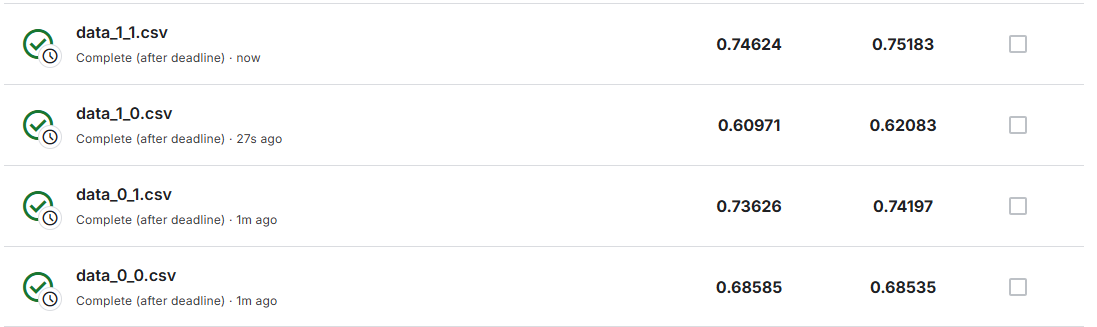

****Получается, что предположение об ошибках в target, по результатам проверки предсказаний, будем считать верным и в дальнейшем пользоваться только этим вариантов тренировочного датасета.****

Подготовим тестовые данные в соответствии с предположением

**Я нашёл пояснение на странице датасета: "predicting the probability that somebody will experience financial distress in the next two years", поэтому target я менять не буду.**

In [1491]:
# data.loc[(data["target"] == 0) & (data["num_90_days_late"] > 0), "target"] = 1
# data.loc[(data["target"] == 1) & (data["num_90_days_late"] == 0), "target"] = 0

## revolving utilization

Беглый осмотр данных с аномальными значениями признака

In [1492]:
data.query(f"revolving_utilization > {feature_extreeme_values.loc["revolving_utilization", 0.9975]}").sample(40)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
136073,0,2.6418,35,1,0.1945,"4,000.0000",5,1,0,3,0.0000
32938,0,8.8519,34,0,0.1685,"12,916.0000",7,0,1,0,0.0000
78444,0,"7,394.0000",71,0,0.7436,"2,331.0000",5,0,2,0,0.0000
125718,0,"12,369.0000",40,2,0.1344,"30,300.0000",5,0,1,0,0.0000
23210,0,143.0000,58,0,0.0008,"5,000.0000",3,0,0,0,0.0000
104902,0,502.0000,28,0,0.2582,"2,083.0000",4,0,0,0,0.0000
63271,1,3.8623,54,0,0.0262,"4,500.0000",0,2,0,2,0.0000
18117,1,2.4947,47,2,14.5780,"1,800.0000",10,0,0,0,0.0000
43778,0,2.4616,50,0,"3,395.0000",NaN,11,0,1,0,0.0000
132663,0,6.4788,41,0,0.3160,"10,525.0000",7,0,1,0,2.0000


Оценка количества экстремальных значений

In [1493]:
revolving_utilization_extreme_values_counts = pd.DataFrame({
    ">1.0": [data[data["revolving_utilization"] > 1.0].shape[0]],
    ">2.0": [data[data["revolving_utilization"] > 2.0].shape[0]],
    ">3.0": [data[data["revolving_utilization"] > 3.0].shape[0]],
    ">5.0": [data[data["revolving_utilization"] > 5.0].shape[0]],
    ">10.0": [data[data["revolving_utilization"] > 10.0].shape[0]],
    ">100.0": [data[data["revolving_utilization"] > 100.0].shape[0]],
    ">1000.0": [data[data["revolving_utilization"] > 1000.0].shape[0]],
    ">10000.0": [data[data["revolving_utilization"] > 10000.0].shape[0]]
}, index=["count"])

In [1494]:
help["оценка количества экстремальных значений в признаке revolving_utilization"] =\
    "revolving_utilization_extreme_values_counts"

In [1495]:
revolving_utilization_extreme_values_counts

,>1.0,>2.0,>3.0,>5.0,>10.0,>100.0,>1000.0,>10000.0
count,3321,371,292,254,241,223,172,16


Оценка связи экстримальных значений с target.

In [1496]:
revolving_utilization_extreme_values_percent_with_target_eq_1 = dict()

for extreme_value in [1.0, 2.0, 3.0, 5.0, 10.0, 100.0, 1000.0, 10000.0]:
    data_over_extreme_value = data.query(f"revolving_utilization > {extreme_value}")
    num_with_target_eq_1 = data_over_extreme_value.query("target == 1").shape[0]
    all_num = data_over_extreme_value.shape[0]
    percent = num_with_target_eq_1 / all_num * 100

    revolving_utilization_extreme_values_percent_with_target_eq_1[f">{extreme_value}"] = [num_with_target_eq_1, all_num, percent]

revolving_utilization_extreme_values_percent_with_target_eq_1 = pd.DataFrame(
    revolving_utilization_extreme_values_percent_with_target_eq_1, index=["with target = 1", "all", "percent"]
)

In [1497]:
help["оценка связи эксремальных значений revolving_utilization с target"] =\
    "revolving_utilization_extreme_values_percent_with_target_eq_1"

In [1498]:
revolving_utilization_extreme_values_percent_with_target_eq_1

,>1.0,>2.0,>3.0,>5.0,>10.0,>100.0,>1000.0,>10000.0
with target = 1,"1,237.0000",54.0000,29.0000,20.0000,17.0000,11.0000,10.0000,0.0000
all,"3,321.0000",371.0000,292.0000,254.0000,241.0000,223.0000,172.0000,16.0000
percent,37.2478,14.5553,9.9315,7.8740,7.0539,4.9327,5.8140,0.0000


**Вывод по значениям признака:**
1. Количество экстремальных, нереалистичных значений, у данного признака не велико, что наталкивает на мысль об ошибках;
2. Смысл данного признака - отношение задолженности по кредитке (кредитной линии не в залог чего-то) к кредитному лемиту по кредитке, поэтому, логично было бы увидеть, что огромная разница в процентах должа вести к большему риску и большему проценту дефолтов. Так как это не наблюдается, то, вероятно, экстримальные значения являются ошибками.
3. Учитывая overdraft системы банков можно предположить, что ещё значения в превышении лемитов до 10 раз могут быть (хотя даже это уже представить трудно), то превышение в 100 и даже больше раз кажутся совсем нереалистичными.

Также как ремарку хочу вставить: это могут быть ошибочными значениями, но не по причине, что что-то неправильно заполнено, а потому что у человека закрытый счёт с очень маленьким долгом, который кто-то не углядел, при закрытии. Поэтому у человека лимит 0, а какой-то долг ещё остался, что и приводит к огромным значениям.

**Предполагаемая обработка признака:**

Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.

1. добавить флаг об аномальности значения с порогом по 99.75 процентилю;
2. выполнить клиппинг значений с порогом по 99.75 процентилю;
3. выполнить логарифмирование признака для выравнивания масштаба значений признака.

## num_30_59_days_late / num_60_89_days_late / num_90_days_late

Беглый осмотр данных с аномальными значениями данных признаков

In [1499]:
data.query(f"num_30_59_days_late > {feature_extreeme_values.loc["num_30_59_days_late", 0.9975]}").sample(40)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
4705,0,1.0000,21,98,0.0000,"2,000.0000",0,98,0,98,0.0000
109194,0,1.0000,22,98,0.0000,NaN,0,98,0,98,0.0000
137981,1,0.0967,51,8,0.4725,"19,250.0000",16,0,10,2,3.0000
129774,0,0.8681,35,7,0.3459,"4,416.0000",14,0,2,3,1.0000
12021,0,1.0000,28,98,0.0000,"2,171.0000",0,98,0,98,0.0000
33591,0,1.0000,29,98,0.0000,"1,854.0000",0,98,0,98,0.0000
51983,1,0.9458,56,9,0.6697,"6,636.0000",23,5,1,2,0.0000
28118,0,1.0000,24,98,0.0000,"1,041.0000",0,98,0,98,0.0000
16663,1,1.0000,54,98,0.0000,NaN,0,98,0,98,0.0000
101307,1,0.8882,53,7,0.4786,"3,430.0000",13,3,1,4,0.0000


Распределение аномальных значений признаков

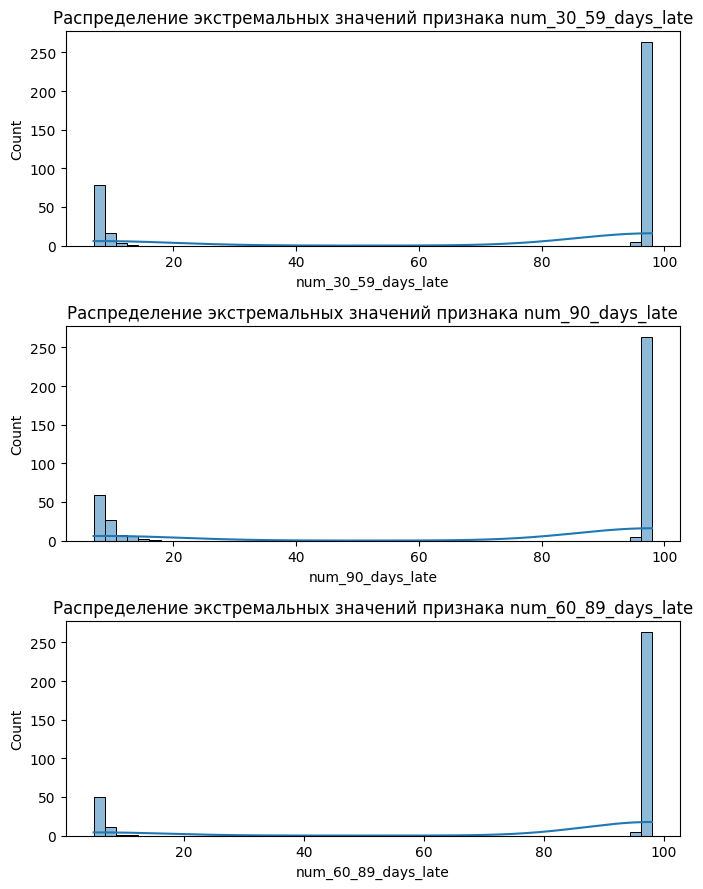

In [1500]:
plt.figure(figsize=(7, 9))

plt.subplot(3, 1, 1)
sns.histplot(data=data.query(f"num_30_59_days_late > {feature_extreeme_values.loc["num_30_59_days_late", 0.9975]}"), x="num_30_59_days_late", bins=50, kde=True)
plt.title("Распределение экстремальных значений признака num_30_59_days_late")

plt.subplot(3, 1, 2)
sns.histplot(data=data.query(f"num_90_days_late > {feature_extreeme_values.loc["num_90_days_late", 0.9975]}"), x="num_90_days_late", bins=50, kde=True)
plt.title("Распределение экстремальных значений признака num_90_days_late")

plt.subplot(3, 1, 3)
sns.histplot(data=data.query(f"num_60_89_days_late > {feature_extreeme_values.loc["num_60_89_days_late", 0.9975]}"), x="num_60_89_days_late", bins=50, kde=True)
plt.title("Распределение экстремальных значений признака num_60_89_days_late")

plt.tight_layout()
plt.show()

Количество строк с num_30_59_days_late, num_60_89_days_late, num_90_days_late не равными одновременно 98

In [1501]:
eq_values_for_features_days_late_98 = data.query("num_30_59_days_late == 98 | num_60_89_days_late == 98 | num_90_days_late == 98")

num_not_all_days_late_eq_98 = eq_values_for_features_days_late_98.shape[0] - eq_values_for_features_days_late_98.query("num_30_59_days_late == num_60_89_days_late == num_90_days_late").shape[0]

In [1502]:
help["Количество строк с num_30_59_days_late, num_60_89_days_late, num_90_days_late не равными одновременно 98"] =\
    "num_not_all_days_late_eq_98"

In [1503]:
num_not_all_days_late_eq_98

0

Количество строк с num_30_59_days_late, num_60_89_days_late, num_90_days_late не равными одновременно 96

In [1504]:
eq_values_for_features_days_late_96 = data.query("num_30_59_days_late == 96 | num_60_89_days_late == 96 | num_90_days_late == 96")

num_not_all_days_late_eq_96 = eq_values_for_features_days_late_96.shape[0] - eq_values_for_features_days_late_96.query("num_30_59_days_late == num_60_89_days_late == num_90_days_late").shape[0]

In [1505]:
help["Количество строк с num_30_59_days_late, num_60_89_days_late, num_90_days_late не равными одновременно 96"] =\
    "num_not_all_days_late_eq_96"

In [1506]:
num_not_all_days_late_eq_96

0

**Вывод по значениям признаков:**

В признаках `num_30_59_days_late`, `num_60_89_days_late`, `num_90_days_late` наблюдется одни и те же аномальные значения 96 или 98. Кроме того, данные значения встречабтся синхронно во всех этих признаках. Всё это наталкивает на мысль о том, что данные значение являются системным кодом, который просочился в данные. Наталкивает на это опять же одновременность наступления и аномальность самих значений, которое в разы отличаются от ближайших значений.

**Предполагаемая обработка признаков:**

Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.

1. добавить флаг о равенстве признаков 96 или 98;
2. значения 96 и 98 преобразуются в особые подобранные значения, которые не будут ломать распределения;
3. выполнить логарифмирование признаков для выравнивания масштаба значений признаков.

## debt ratio

Беглый осмотр данных с аномальными значениями признака

In [1507]:
data.query(f"debt_ratio > {feature_extreeme_values.loc["debt_ratio", 0.9975]}").sort_values(by="debt_ratio").tail(40)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
51173,0,0.4092,74,0,"20,637.0000",NaN,8,0,5,0,0.0000
66929,1,0.0630,94,1,"20,809.0000",0.0000,13,1,0,1,0.0000
112426,1,0.0123,52,2,"20,948.0000",NaN,10,0,6,0,NaN
13065,0,0.0615,41,0,"21,377.0000",NaN,13,0,7,0,0.0000
104097,0,0.5324,61,0,"21,386.0000",NaN,23,0,5,0,0.0000
144887,1,"8,328.0000",39,0,"21,395.0000",NaN,9,0,2,1,0.0000
56816,0,1.0000,60,2,"21,727.0000",NaN,12,2,0,0,0.0000
76188,1,0.4359,62,2,"24,466.0000",NaN,25,0,15,0,NaN
24800,0,0.4957,69,0,"24,475.0000",NaN,14,0,1,0,0.0000
105259,0,0.0098,47,0,"24,496.0000",NaN,20,0,10,0,NaN


Оценка процента пропусков и низких значений monthly_income у экстремальных значений debt_ratio

In [1508]:
num_missing_income_in_extreeme_value_debt = dict()
for percentile in [0.5, 0.6, 0.7, 0.8, 0.9, 0.99, 0.995, 0.9975]:
    val_percentile = data["debt_ratio"].quantile(percentile)
    num_missing = data.query(f"debt_ratio > {val_percentile} & monthly_income.notna() == False").shape[0]
    num_with_low_or_mis_value = data.query(f"debt_ratio > {val_percentile} & (monthly_income < 1000 | monthly_income.notna() == False)").shape[0]
    all_num = data.query(f"debt_ratio > {val_percentile}").shape[0]

    num_missing_income_in_extreeme_value_debt[f"pecentrile debt ratio {percentile*100}"] = [
        val_percentile,
        num_missing,
        all_num,
        num_missing / all_num * 100,
        num_with_low_or_mis_value,
        all_num,
        num_with_low_or_mis_value / all_num * 100
    ]

num_missing_income_in_extreeme_value_debt = pd.DataFrame(num_missing_income_in_extreeme_value_debt, index=[
    "val percentile", "num missing", "all_num", "num missing percent", "num with low or mis value", "all num", "num with low or mis value percentile"
])

In [1509]:
help["Оценка процента пропусков и низких значений monthly_income у эксремальных значений debt_ratio"] =\
    "num_missing_income_in_extreeme_value_debt"

In [1510]:
num_missing_income_in_extreeme_value_debt

,pecentrile debt ratio 50.0,pecentrile debt ratio 60.0,pecentrile debt ratio 70.0,pecentrile debt ratio 80.0,pecentrile debt ratio 90.0,pecentrile debt ratio 99.0,pecentrile debt ratio 99.5,pecentrile debt ratio 99.75
val percentile,0.3665,0.4675,0.6492,4.0000,"1,267.0000","4,979.0400","6,186.0100","7,805.0025"
num missing,"28,109.0000","28,109.0000","28,109.0000","27,427.0000","14,146.0000","1,415.0000",705.0000,347.0000
all_num,"75,000.0000","60,000.0000","44,999.0000","29,891.0000","14,995.0000","1,500.0000",750.0000,375.0000
num missing percent,37.4787,46.8483,62.4658,91.7567,94.3381,94.3333,94.0000,92.5333
num with low or mis value,"31,436.0000","31,363.0000","31,200.0000","29,722.0000","14,995.0000","1,500.0000",750.0000,375.0000
all num,"75,000.0000","60,000.0000","44,999.0000","29,891.0000","14,995.0000","1,500.0000",750.0000,375.0000
num with low or mis value percentile,41.9147,52.2717,69.3349,99.4346,100.0000,100.0000,100.0000,100.0000


Количество представителей с малым income и аномальным debt ratio

In [1511]:
num_low_income_in_extreeme_value_debt = dict()
for percentile in [0.5, 0.6, 0.7, 0.8, 0.9, 0.99, 0.995, 0.9975]:
    val_percentile = data["debt_ratio"].quantile(percentile)

    num_with_low_montly_income = data.query(f"debt_ratio > {val_percentile} & monthly_income < 500").shape[0]
    all_num = data.query(f"debt_ratio >= {val_percentile}").shape[0]
    percent = num_with_low_montly_income / all_num * 100

    num_low_income_in_extreeme_value_debt[f"pecentrile debt ratio {percentile*100}"] = [
        val_percentile,
        num_with_low_montly_income,
        all_num,
        percent
    ]

num_low_income_in_extreeme_value_debt = pd.DataFrame(num_low_income_in_extreeme_value_debt, index=[
    "val percentile", "num_with_low_montly_income", "all", "percent"
])

In [1512]:
help["Количество представителей с малым income и аномальным debt ratio"] =\
    "num_low_income_in_extreeme_value_debt"

In [1513]:
num_low_income_in_extreeme_value_debt

,pecentrile debt ratio 50.0,pecentrile debt ratio 60.0,pecentrile debt ratio 70.0,pecentrile debt ratio 80.0,pecentrile debt ratio 90.0,pecentrile debt ratio 99.0,pecentrile debt ratio 99.5,pecentrile debt ratio 99.75
val percentile,0.3665,0.4675,0.6492,4.0000,"1,267.0000","4,979.0400","6,186.0100","7,805.0025"
num_with_low_montly_income,"2,405.0000","2,393.0000","2,376.0000","2,199.0000",849.0000,85.0000,45.0000,28.0000
all,"75,000.0000","60,000.0000","45,001.0000","30,065.0000","15,004.0000","1,500.0000",750.0000,375.0000
percent,3.2067,3.9883,5.2799,7.3142,5.6585,5.6667,6.0000,7.4667


Корреляция экстремальных значений признака с target = 1

In [1514]:
num_extreeme_value_debt_with_target_eq_1 = dict()
for percentile in [0.5, 0.6, 0.7, 0.8, 0.9, 0.99, 0.995, 0.9975]:
    val_percentile = data["debt_ratio"].quantile(percentile)

    data_over_extreme_value = data.query(f"debt_ratio > {val_percentile}")
    num_with_target_eq_1 = data_over_extreme_value.query("target == 1").shape[0]
    all_num = data_over_extreme_value.shape[0]
    percent = num_with_target_eq_1 / all_num * 100

    num_extreeme_value_debt_with_target_eq_1[f"pecentrile debt ratio {percentile*100}"] = [
        val_percentile,
        num_with_target_eq_1,
        all_num,
        percent
    ]

num_extreeme_value_debt_with_target_eq_1 = pd.DataFrame(num_extreeme_value_debt_with_target_eq_1, index=[
    "val percentile", "num_with_target_eq_1", "all", "percent"
])

In [1515]:
help["Корреляция экстремальных значений с target = 1"] =\
    "num_extreeme_value_debt_with_target_eq_1"

In [1516]:
num_extreeme_value_debt_with_target_eq_1

,pecentrile debt ratio 50.0,pecentrile debt ratio 60.0,pecentrile debt ratio 70.0,pecentrile debt ratio 80.0,pecentrile debt ratio 90.0,pecentrile debt ratio 99.0,pecentrile debt ratio 99.5,pecentrile debt ratio 99.75
val percentile,0.3665,0.4675,0.6492,4.0000,"1,267.0000","4,979.0400","6,186.0100","7,805.0025"
num_with_target_eq_1,"5,638.0000","4,627.0000","3,365.0000","1,653.0000",747.0000,112.0000,61.0000,34.0000
all,"75,000.0000","60,000.0000","44,999.0000","29,891.0000","14,995.0000","1,500.0000",750.0000,375.0000
percent,7.5173,7.7117,7.4779,5.5301,4.9817,7.4667,8.1333,9.0667


**Вывод по значениям признака:**

1. Во многом аномальные значения debt ratio объясняются пропусками в значениях monthly income;
2. Оставшиеся аномальные значения, могут в некоторой степени объясняться потерей зароботка заёмщиком;
3. Возможно, в принципе, оставшиеся значения могут быть ошибочными.

**Предполагаемая обработка признака:**

Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.

1. добавить флаг об аномальности значения с порогом по 90 процентилю;
2. выполнить клиппинг значений с порогом по 90 процентилю;
3. выполнить логарифмирование признака для выравнивания масштаба значений признака.

## monthly income

Беглый осмотр данных с аномальными значениями признака

In [1517]:
data.query(f"monthly_income > {feature_extreeme_values.loc["monthly_income", 0.9975]} | monthly_income < 1000").sample(40)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
83186,0,0.0882,67,0,"3,004.0000",0.0000,6,0,1,0,0.0000
75624,1,0.0714,46,1,1.4025,635.0000,7,0,0,0,0.0000
53446,0,0.0362,49,1,4.9095,750.0000,18,0,2,0,0.0000
100955,0,1.0000,33,0,199.0000,1.0000,1,0,0,0,0.0000
96423,0,0.1182,39,0,929.0000,1.0000,3,0,1,0,1.0000
33415,0,1.0000,21,0,0.0000,864.0000,1,0,0,0,0.0000
117435,0,0.0679,68,0,0.0335,"90,000.0000",11,0,2,0,0.0000
65063,0,0.0151,56,0,7.7214,200.0000,10,0,1,0,0.0000
35812,0,0.6075,25,1,750.0000,0.0000,7,0,0,0,5.0000
102156,0,0.0000,30,0,0.8719,600.0000,2,0,0,0,0.0000


Распределение экстремальных значений признака

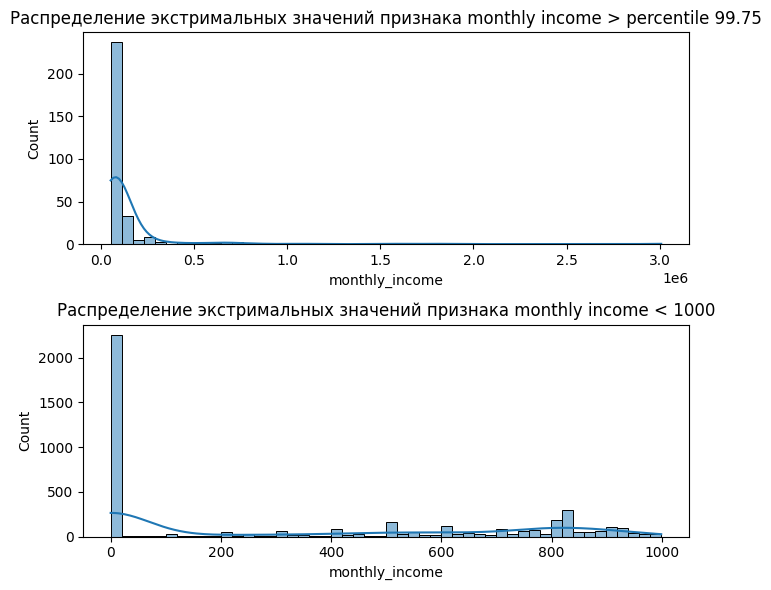

In [1518]:
plt.figure(figsize=(7, 6))

plt.subplot(2, 1, 1)
sns.histplot(data=data.query(f"monthly_income > {feature_extreeme_values.loc["monthly_income", 0.9975]}"), x="monthly_income", bins=50, kde=True)
plt.title("Распределение экстримальных значений признака monthly income > percentile 99.75")

plt.subplot(2, 1, 2)
sns.histplot(data=data.query(f"monthly_income < 1000"), x="monthly_income", bins=50, kde=True)
plt.title("Распределение экстримальных значений признака monthly income < 1000")

plt.tight_layout()
plt.show()

Количество экстремальных значений признака

In [1519]:
num_extreeme_values_monthly_income = pd.DataFrame({
    "<1000": [data.query("monthly_income < 1000").shape[0]],
    ">50000": [data.query("monthly_income > 50000").shape[0]],
    ">100000": [data.query("monthly_income > 100000").shape[0]],
    ">200000": [data.query("monthly_income > 200000").shape[0]],
    ">300000": [data.query("monthly_income > 300000").shape[0]],
    ">500000": [data.query("monthly_income > 500000").shape[0]],
    ">1000000": [data.query("monthly_income > 1000000").shape[0]],
    ">2000000": [data.query("monthly_income > 2000000").shape[0]]
}, index=["count"])

In [1520]:
help["Количество экстремальных значений признака monthly income"] = "num_extreeme_values_monthly_income"

In [1521]:
num_extreeme_values_monthly_income

,<1000,>50000,>100000,>200000,>300000,>500000,>1000000,>2000000
count,4428,301,70,29,17,12,4,1


Корреляция экстремально больших значений признака с target = 1

In [1522]:
corr_target_with_extreme_monthly_income_value = dict()

for extreme_value in [50000, 100000, 200000, 300000, 500000, 1000000, 2000000]:
    data_over_extreme_value = data.query(f"monthly_income > {extreme_value}")
    num_target_eq_1 = data_over_extreme_value.query("target == 1").shape[0]
    all_num = data_over_extreme_value.shape[0]
    percent = num_target_eq_1 / all_num * 100

    corr_target_with_extreme_monthly_income_value[f">{extreme_value}"] = [num_target_eq_1, all_num, percent]

corr_target_with_extreme_monthly_income_value = pd.DataFrame(corr_target_with_extreme_monthly_income_value, index=[
    "num with target = 1", "all", "percent"
])

In [1523]:
help["корреляция target = 1 с аномальными значениями monthly income"] = "corr_target_with_extreme_monthly_income_value"

In [1524]:
corr_target_with_extreme_monthly_income_value

,>50000,>100000,>200000,>300000,>500000,>1000000,>2000000
num with target = 1,17.0000,3.0000,2.0000,0.0000,0.0000,0.0000,0.0000
all,301.0000,70.0000,29.0000,17.0000,12.0000,4.0000,1.0000
percent,5.6478,4.2857,6.8966,0.0000,0.0000,0.0000,0.0000


**Вывод по значениям признака:**
1. В целом можно сказать, что в признаке нет ошибочных значений среди эксремальных значений;
2. В признаке явно есть выбросы - огромные значения, которые нужно как-то обработать;
3. В целом малые значения, кроме nan, почти не связаны с экстремальными значениями debt_ratio, поэтому нужно будет делать флаг не по малому monthly_income, а по большому debt_ratio.

**Предполагаемая обработка признака:**

Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.

1. добавить флаг об аномальности значения с порогом по 99.75 процентилю;
2. выполнить клиппинг значений с порогом по 99.75 процентилю;
3. выполнить логарифмирование признака для выравнивания масштаба значений признака.

## num open credit lines

Беглый осмотр данных с аномальными значениями признака

In [1525]:
data.query(f"num_open_credit_lines > {feature_extreeme_values.loc["num_open_credit_lines", 0.9975]}").sample(40)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
18259,0,0.6354,61,6,0.4294,"48,000.0000",33,1,26,0,1.0000
71904,0,0.2372,55,0,0.8109,"8,513.0000",46,0,4,0,0.0000
120454,0,0.0457,47,0,1.0208,"4,333.0000",33,0,2,0,0.0000
16930,0,0.5709,61,0,0.4900,"8,608.0000",31,0,1,0,1.0000
27269,0,0.3424,68,0,0.5690,"6,667.0000",32,0,1,0,1.0000
6035,0,0.5854,70,0,1.8407,"4,700.0000",32,0,7,0,0.0000
26359,0,0.4445,66,0,0.4788,"11,958.0000",35,0,2,0,0.0000
72968,0,0.0966,67,0,0.8886,"3,500.0000",31,0,2,0,0.0000
122531,0,0.0094,69,0,2.2423,"5,083.0000",34,0,16,0,0.0000
143356,0,0.0181,71,0,0.0303,"10,500.0000",52,0,0,0,0.0000


Распределение экстремальных значений признака

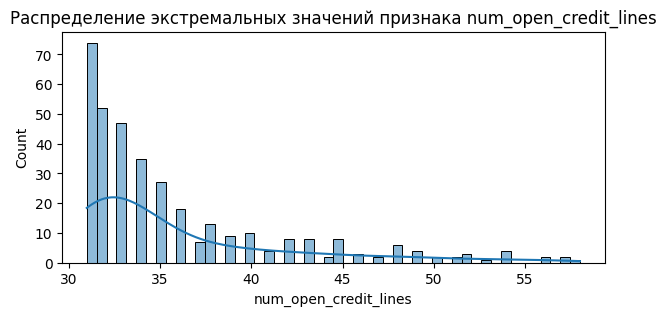

In [1526]:
plt.figure(figsize=(7, 3))
sns.histplot(data=data.query(f"num_open_credit_lines > {feature_extreeme_values.loc["num_open_credit_lines", 0.9975]}"), x="num_open_credit_lines", bins=50, kde=True)
plt.title("Распределение экстремальных значений признака num_open_credit_lines")
plt.show()

Корреляция экстремально больших значений признака с target = 1

In [1527]:
corr_target_with_extreme_value = dict()

for extreme_value in [30, 35, 40, 45, 50]:
    data_over_extreme_value = data.query(f"num_open_credit_lines > {extreme_value}")
    num_target_1 = data_over_extreme_value.query("target == 1").shape[0]
    all_num = data_over_extreme_value.shape[0]
    percent = num_target_1 / all_num * 100

    corr_target_with_extreme_value[f">{extreme_value}"] = [num_target_1, all_num, percent]

corr_target_with_extreme_value = pd.DataFrame(corr_target_with_extreme_value, index=["with target = 1", "all", "percent"])

In [1528]:
help["корреляция экстремально больших значений признака num_open_credit_lines с target = 1"] =\
    "corr_target_with_extreme_value"

In [1529]:
corr_target_with_extreme_value

,>30,>35,>40,>45,>50
with target = 1,26.0000,14.0000,8.0000,5.0000,2.0000
all,354.0000,119.0000,62.0000,32.0000,15.0000
percent,7.3446,11.7647,12.9032,15.6250,13.3333


**Вывод по значениям признака:**

1. Пусть и есть выбросы, такие значения выглядят достаточно правдоподобно;
2. Ошибок в признаке нет;
3. Большого разброса по числам тут нет, хотя и по смыслу они есть. В принципе данный признак сам по себе является не плохим.

**Предполагаемая обработка признака:**

Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.

1. добавить флаг об аномальности значения с порогом по 99.75 процентилю;
2. выполнить клиппинг значений с порогом по 99.75 процентилю;
3. выполнить логарифмирование признака для выравнивания масштаба значений признака.

## num real estate loans

Беглый осмотр данных с аномальными значениями в признаке

In [1530]:
data.query(f"num_real_estate_loans > {feature_extreeme_values.loc["num_real_estate_loans", 0.9975]}").sample(40)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
17779,0,0.0731,40,0,0.5100,"21,725.0000",18,0,8,0,2.0000
44686,0,0.2335,73,7,0.7893,"13,799.0000",24,0,14,3,0.0000
53592,0,0.3732,40,0,5.8824,"3,816.0000",26,0,15,0,0.0000
19107,0,1.0000,62,0,"12,847.0000",NaN,10,0,8,0,0.0000
32058,1,0.2155,52,3,1.6289,"6,000.0000",15,0,10,0,3.0000
107723,1,0.1039,74,4,0.6734,"16,279.0000",28,0,16,0,0.0000
128696,0,0.0346,76,2,2.0543,"8,377.0000",27,0,15,0,1.0000
56936,0,0.2574,39,0,0.7357,"10,000.0000",16,0,8,0,0.0000
51251,0,0.8001,68,3,0.3503,"40,750.0000",31,0,9,0,2.0000
6453,0,0.0678,43,0,0.6088,"17,525.0000",18,0,10,0,3.0000


Распределение экстемальных значений признака

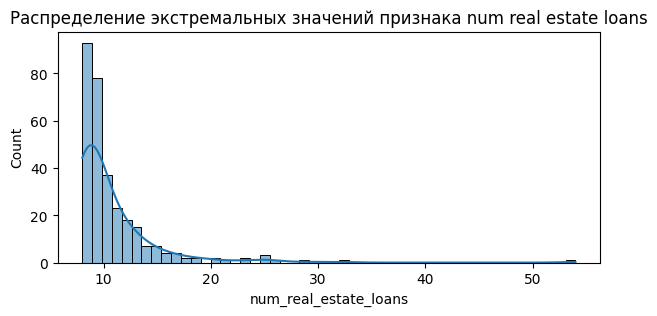

In [1531]:
plt.figure(figsize=(7, 3))
sns.histplot(data=data.query(f"num_real_estate_loans > {feature_extreeme_values.loc["num_real_estate_loans", 0.9975]}"), x="num_real_estate_loans", bins=50, kde=True)
plt.title("Распределение экстремальных значений признака num real estate loans")
plt.show()

Распределение monthly_income в бинах num_real_estate_loans.

d:\Pet Projects\ML\give_me_some_credit\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
d:\Pet Projects\ML\give_me_some_credit\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


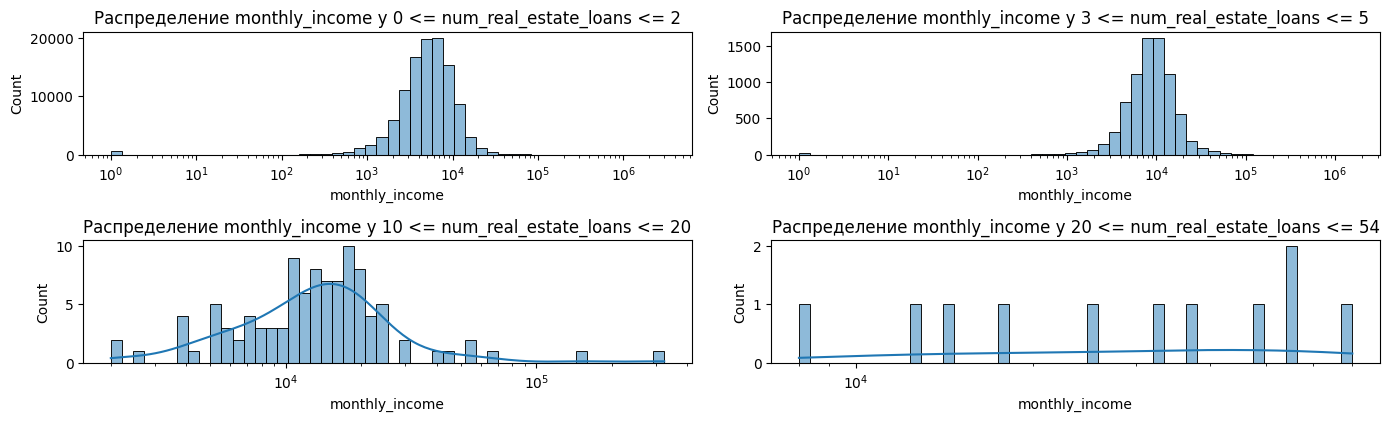

In [1532]:
plt.figure(figsize=(14, 8))

for i, (left, right) in enumerate([(0, 2), (3, 5), (10, 20), (20, 54)]):
    temp = data.query(f"num_real_estate_loans >= {left} & num_real_estate_loans <= {right}")
    
    plt.subplot(4, 2, i+1)
    sns.histplot(data=temp, x="monthly_income", bins=50, kde=True, log_scale=True)
    plt.title(f"Распределение monthly_income у {left} <= num_real_estate_loans <= {right}")
    
plt.tight_layout()
plt.show()

Корреляция экстремальных значений признака с target = 1

In [1533]:
corr_target_eq_1_with_num_real_estate_loans_extreme_value = dict()

for extreme_value in [7, 10, 13, 16, 20, 30, 40]:
    over_extreme_value = data.query(f"num_real_estate_loans > {extreme_value}")
    num_with_target_1 = over_extreme_value.query("target == 1").shape[0]
    all_num = over_extreme_value.shape[0]
    percent = num_with_target_1 / all_num * 100

    corr_target_eq_1_with_num_real_estate_loans_extreme_value[f">{extreme_value}"] = [num_with_target_1, all_num, percent]

corr_target_eq_1_with_num_real_estate_loans_extreme_value = pd.DataFrame(corr_target_eq_1_with_num_real_estate_loans_extreme_value, index=["with target = 1", "all", "percent"])

In [1534]:
help["корреляция экстремальных значений num_real_estate_loans с target = 1"] =\
    "corr_target_eq_1_with_num_real_estate_loans_extreme_value"

In [1535]:
corr_target_eq_1_with_num_real_estate_loans_extreme_value

,>7,>10,>13,>16,>20,>30,>40
with target = 1,63.0000,21.0000,8.0000,4.0000,2.0000,0.0000,0.0000
all,302.0000,94.0000,38.0000,20.0000,10.0000,2.0000,1.0000
percent,20.8609,22.3404,21.0526,20.0000,20.0000,0.0000,0.0000


**Вывод по значениям признака:**
1. В целом признак пусть и странноватый (не верится, что можно взять 5 и более кредитов под залог авто и дома), но значения в нём не выглядят ошибочными;
2. Выбросы, можно сказать, всё равно присутствуют, так как максимальное значение сильно отличается от среднего;
3. При проверке совметсного распределения monthly_income и num_real_estate_loans почти не обнаружено странностей типа малый monthly_income при высоком num_real_estate_loans, что ещё раз подтверждает гипотезу о том, что с данным признаком всё нормально.

**Предполагаемая обработка признака:**

Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.

1. добавить флаг об аномальности значения с порогом по 99.75 процентилю;
2. выполнить клиппинг значений с порогом по 99.75 процентилю;
3. выполнить логарифмирование признака для выравнивания масштаба значений признака.

## num_dependents

Беглый осмотр данных с аномальными значениями в признаке

In [1536]:
data.query(f"num_dependents > {feature_extreeme_values.loc["num_dependents", 0.9975]}").sample(40)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
75420,0,0.5453,53,1,0.1148,"7,500.0000",4,0,0,0,6.0000
96253,0,0.8166,44,0,0.3452,"4,000.0000",4,0,0,0,6.0000
87843,0,0.0349,49,0,0.0167,"9,416.0000",9,0,0,0,7.0000
110616,0,0.3326,51,0,0.2677,"9,000.0000",9,0,2,0,6.0000
5375,0,0.9767,44,0,0.1953,"11,858.0000",6,0,0,0,6.0000
85749,0,0.0213,48,0,0.3022,"16,000.0000",9,0,2,0,6.0000
149733,0,0.4622,57,0,0.3768,"11,084.0000",19,0,1,0,6.0000
110648,0,0.3705,51,0,0.1717,"15,476.0000",16,0,0,0,6.0000
5420,0,0.5772,58,0,0.2366,"11,500.0000",7,0,2,1,7.0000
42271,0,0.0028,47,2,0.0007,"9,000.0000",10,1,0,0,6.0000


Распределение экстремальных значений признака

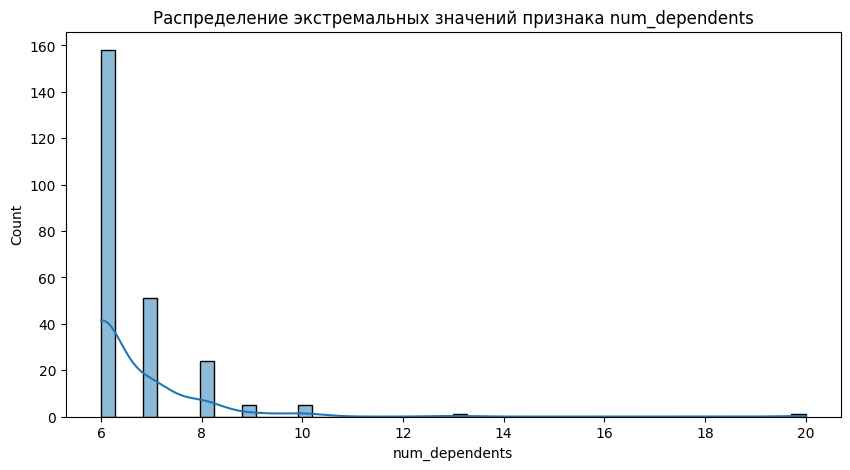

In [1537]:
plt.figure(figsize=(10, 5))
sns.histplot(data=data.query(f"num_dependents > {feature_extreeme_values.loc["num_dependents", 0.9975]}"), x="num_dependents", bins=50, kde=True)
plt.title("Распределение экстремальных значений признака num_dependents")
plt.show()

Корреляция экстремальных значений в признаке с target = 1

In [1538]:
corr_target_eq_1_with_num_dependents_extreme_value = dict()

for extreme_value in [4, 5, 6, 8, 10, 12]:
    over_extreme_value = data.query(f"num_dependents > {extreme_value}")
    num_with_target_1 = over_extreme_value.query("target == 1").shape[0]
    all_num = over_extreme_value.shape[0]
    percent = num_with_target_1 / all_num * 100

    corr_target_eq_1_with_num_dependents_extreme_value[f">{extreme_value}"] = [num_with_target_1, all_num, percent]

corr_target_eq_1_with_num_dependents_extreme_value = pd.DataFrame(corr_target_eq_1_with_num_dependents_extreme_value, index=["with target = 1", "all", "percent"])

In [1539]:
help["корреляция экстремальных значений num_dependents с target = 1"] =\
    "corr_target_eq_1_with_num_dependents_extreme_value"

In [1540]:
corr_target_eq_1_with_num_dependents_extreme_value

,>4,>5,>6,>8,>10,>12
with target = 1,99.0000,31.0000,7.0000,0.0000,0.0000,0.0000
all,991.0000,245.0000,87.0000,12.0000,2.0000,2.0000
percent,9.9899,12.6531,8.0460,0.0000,0.0000,0.0000


Анализ пропусков в признаке

In [1541]:
data.query("num_dependents.notna() == False").sample(40)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
92030,0,1.0000,21,0,3.0000,NaN,2,0,0,0,NaN
82293,0,0.0000,69,0,53.0000,NaN,3,0,0,0,NaN
119615,0,0.5504,44,0,"2,346.0000",NaN,5,0,1,0,NaN
27162,0,0.1233,26,0,5.0000,NaN,3,0,0,0,NaN
32884,0,0.1087,67,0,147.0000,NaN,5,0,0,0,NaN
21009,0,0.1147,68,0,"2,408.0000",NaN,6,0,1,0,NaN
140331,0,0.0000,24,0,45.0000,NaN,5,0,0,0,NaN
23666,0,1.5575,38,0,"2,505.0000",NaN,7,0,1,0,NaN
73138,0,0.5909,45,0,"1,752.0000",NaN,2,0,1,0,NaN
70257,0,0.0000,51,0,"5,549.0000",NaN,10,0,2,0,NaN


Корреляция nanов в num_dependents с nanами в monthly_income

In [1542]:
data_with_nan_in_num_dependents = data.query(f"num_dependents.notna() == False")
percent_nan_monthly_income_in_nan_num_dependents =\
    data_with_nan_in_num_dependents.shape[0] / data_with_nan_in_num_dependents.query("monthly_income.notna() == False").shape[0] * 100

In [1543]:
help["Корреляция nanов в num_dependents с nanами в monthly_income"] =\
    percent_nan_monthly_income_in_nan_num_dependents

In [1544]:
percent_nan_monthly_income_in_nan_num_dependents

100.0

**Вывод по значениям признака:**
1. В признаке есть выбросы;
2. Не похоже, что в признаке есть ошибки;
3. Пропуск в количестве иждевенцев совпадает с пропусками в monthly_income (обратное не верно).

**Предполагаемая обработка признака:**

Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.

1. добавить флаг об аномальности значения с порогом по 99.75 процентилю;
2. выполнить клиппинг значений с порогом по 99.75 процентилю;
3. выполнить логарифмирование признака для выравнивания масштаба значений признака.

# Резюме анализа значений признаков

In [1545]:
summary_features_values_analysis = pd.DataFrame({
    "feature": [
        "revolving_utilization",
        "age",
        "num_30_59_days_late, num_60_89_days_late, num_90_days_late",
        "debt_ratio",
        "monthly_income",
        "num_open_credit_lines",
        "num_real_estate_loans",
        "num_dependents"
    ],
    "наличие пропусков": [
        "нет",
        "нет",
        "нет",
        "нет",
        "да",
        "нет",
        "нет",
        "да"
    ],
    "объяснение пропусков и корреляция с target = 1": [
        "-",
        "-",
        "-",
        "-",
        "просто пропуски и всё; отрицательная, но до конца не ясно",
        "-",
        "-",
        "просто пропуски и всё; -"
    ],
    "наличие экстремальных значений": [
        "да",
        "нет",
        "да - 96 и 98",
        "да",
        "да",
        "да",
        "да",
        "да"

    ],
    "причины появления экстремальных значений": [
        "вероятнее всего это ошибки либо системы, либо записей",
        "-",
        "системные коды, которые просочились в данные",
        "скорее всего они связаны с отсутствием или низкими значениями monthly_income, что и повлияло на аномально большие значения признака",
        "просто особенные представители, ошибок нет",
        "просто особенные представители, ошибок нет",
        "просто особенные представители, ошибок нет",
        "просто особенные представители, ошибок нет"
    ],
    "корреляция экстремальных значений с target = 1": [
        "отрицательная, что наталкивает дополнительно на мысли об ошибках",
        "-",
        "-",
        "скорее отрицательная, но до конца не понятно",
        "отрицательная, но до конца не понятно",
        "не ясно",
        "не ясно",
        "отрицательная, но до конца не понятно"
    ],
    "предполагаемая обработка признака": [
        "Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.\n\n1. добавить флаг об аномальности значения с порогом по 99.75 процентилю;\n2. выполнить клиппинг значений с порогом по 99.75 процентилю;\n3. выполнить логарифмирование признака для выравнивания масштаба значений признака.",
        "-",
        "Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.\n\n1. добавить флаг о равенстве признаков 96 или 98;\n2. значения 96 и 98 преобразуются в особые подобранные значения, которые не будут ломать распределения;\n3. выполнить логарифмирование признаков для выравнивания масштаба значений признаков.",
        "Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.\n\n1. добавить флаг об аномальности значения с порогом по 90 процентилю;\n2. выполнить клиппинг значений с порогом по 90 процентилю;\n3. выполнить логарифмирование признака для выравнивания масштаба значений признака.",
        "Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.\n\n1. добавить флаг об аномальности значения с порогом по 99.75 процентилю;\n2. выполнить клиппинг значений с порогом по 99.75 процентилю;\n3. выполнить логарифмирование признака для выравнивания масштаба значений признака.",
        "Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.\n\n1. добавить флаг об аномальности значения с порогом по 99.75 процентилю;\n2. выполнить клиппинг значений с порогом по 99.75 процентилю;\n3. выполнить логарифмирование признака для выравнивания масштаба значений признака.",
        "Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.\n\n1. добавить флаг об аномальности значения с порогом по 99.75 процентилю;\n2. выполнить клиппинг значений с порогом по 99.75 процентилю;\n3. выполнить логарифмирование признака для выравнивания масштаба значений признака.",
        "Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.\n\n1. добавить флаг об аномальности значения с порогом по 99.75 процентилю;\n2. выполнить клиппинг значений с порогом по 99.75 процентилю;\n3. выполнить логарифмирование признака для выравнивания масштаба значений признака."
    ]
})

In [1546]:
summary_features_values_analysis.style.set_properties(**{
    "text-align": "left",
    "white-space": "pre-wrap"
})

,feature,наличие пропусков,объяснение пропусков и корреляция с target = 1,наличие экстремальных значений,причины появления экстремальных значений,корреляция экстремальных значений с target = 1,предполагаемая обработка признака
0,revolving_utilization,нет,-,да,"вероятнее всего это ошибки либо системы, либо записей","отрицательная, что наталкивает дополнительно на мысли об ошибках","Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн. 1. добавить флаг об аномальности значения с порогом по 99.75 процентилю; 2. выполнить клиппинг значений с порогом по 99.75 процентилю; 3. выполнить логарифмирование признака для выравнивания масштаба значений признака."
1,age,нет,-,нет,-,-,-
2,"num_30_59_days_late, num_60_89_days_late, num_90_days_late",нет,-,да - 96 и 98,"системные коды, которые просочились в данные",-,"Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн. 1. добавить флаг о равенстве признаков 96 или 98; 2. значения 96 и 98 преобразуются в особые подобранные значения, которые не будут ломать распределения; 3. выполнить логарифмирование признаков для выравнивания масштаба значений признаков."
3,debt_ratio,нет,-,да,"скорее всего они связаны с отсутствием или низкими значениями monthly_income, что и повлияло на аномально большие значения признака","скорее отрицательная, но до конца не понятно","Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн. 1. добавить флаг об аномальности значения с порогом по 90 процентилю; 2. выполнить клиппинг значений с порогом по 90 процентилю; 3. выполнить логарифмирование признака для выравнивания масштаба значений признака."
4,monthly_income,да,"просто пропуски и всё; отрицательная, но до конца не ясно",да,"просто особенные представители, ошибок нет","отрицательная, но до конца не понятно","Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн. 1. добавить флаг об аномальности значения с порогом по 99.75 процентилю; 2. выполнить клиппинг значений с порогом по 99.75 процентилю; 3. выполнить логарифмирование признака для выравнивания масштаба значений признака."
5,num_open_credit_lines,нет,-,да,"просто особенные представители, ошибок нет",не ясно,"Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн. 1. добавить флаг об аномальности значения с порогом по 99.75 процентилю; 2. выполнить клиппинг значений с порогом по 99.75 процентилю; 3. выполнить логарифмирование признака для выравнивания масштаба значений признака."
6,num_real_estate_loans,нет,-,да,"просто особенные представители, ошибок нет",не ясно,"Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн. 1. добавить флаг об аномальности значения с порогом по 99.75 процентилю; 2. выполнить клиппинг значений с порогом по 99.75 процентилю; 3. выполнить логарифмирование признака для выравнивания масштаба значений признака."
7,num_dependents,да,просто пропуски и всё; -,да,"просто особенные представители, ошибок нет","отрицательная, но до конца не понятно","Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн. 1. добавить флаг об аномальности значения с порогом по 99.75 процентилю; 2. выполнить клиппинг значений с порогом по 99.75 процентилю; 3. выполнить логарифмирование признака для выравнивания масштаба значений признака."


In [1547]:
help["Резюме анализа значений признаков"] = "summary_features_values_analysis"